# ZINC Molecular-Generation Development

This notebook is the maintained ZINC-focused Conditional Node Field demo.

It downloads a large ZINC molecular table once, caches the converted NetworkX molecular graphs on disk, and lets you resume later without rebuilding the dataset or retraining the generator.

In [6]:
# Enable inline plotting and autoreload for ZINC exploration.
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from IPython.core.display import HTML
from sklearn.model_selection import train_test_split

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

from conditional_node_field_graph_generator.notebooks import configure_notebook

globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.extensions.demo.pipeline import (
    build_graph_generator,
    prepare_zinc_data_split,
    fit_graph_generator,
)
from conditional_node_field_graph_generator.extensions.demo.storage import (
    find_latest_checkpoint,
    list_training_checkpoints,
)
from abstractgraph_graphicalizer.chem import (
    draw_molecules,
    smiles_to_graph,
)
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
    save_graph_generator,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.13.0
CUDA available: False


## Helpers

The helper cell below keeps the molecule display and sampling utilities local to this notebook, including a simple endpoint sampler for interpolation experiments.

In [7]:
# Import display and summary utilities.


def label_counter(graphs, kind="node"):
    counts = {}
    if kind == "node":
        for graph in graphs:
            for _, attrs in graph.nodes(data=True):
                label = attrs.get("label")
                counts[label] = counts.get(label, 0) + 1
    elif kind == "edge":
        for graph in graphs:
            for _, _, attrs in graph.edges(data=True):
                label = attrs.get("label")
                counts[label] = counts.get(label, 0) + 1
    else:
        raise ValueError("kind must be 'node' or 'edge'")
    return dict(sorted(counts.items(), key=lambda item: str(item[0])))


def summarize_graphs(graphs, prefix="dataset"):
    node_counts = np.array([graph.number_of_nodes() for graph in graphs], dtype=int)
    edge_counts = np.array([graph.number_of_edges() for graph in graphs], dtype=int)
    print(f"{prefix}: {len(graphs)} graphs")
    print(
        f"{prefix}: node count min/median/max = "
        f"{node_counts.min()}/{int(np.median(node_counts))}/{node_counts.max()}"
    )
    print(
        f"{prefix}: edge count min/median/max = "
        f"{edge_counts.min()}/{int(np.median(edge_counts))}/{edge_counts.max()}"
    )
    print(f"{prefix}: node labels = {label_counter(graphs, 'node')}")
    print(f"{prefix}: edge labels = {label_counter(graphs, 'edge')}")


def show_seed_and_samples(
    graph_generator,
    seed_graphs,
    n_seeds=6,
    title="Samples",
    apply_feasibility_filtering=None,
    feasibility_oracle_candidates_per_attempt=None,
):
    # Show conditioning molecules first, then raw decoded samples, then feasibility-filtered samples.
    if apply_feasibility_filtering is None:
        apply_feasibility_filtering = APPLY_FEASIBILITY_FILTERING
    if feasibility_oracle_candidates_per_attempt is None:
        feasibility_oracle_candidates_per_attempt = FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT
    feasibility_estimator = getattr(graph_generator, "feasibility_estimator", None)
    if feasibility_estimator is None:
        if apply_feasibility_filtering or feasibility_oracle_candidates_per_attempt:
            print("Feasibility support is unavailable for this graph generator; sampling without feasibility filtering or oracle.")
        apply_feasibility_filtering = False
        feasibility_oracle_candidates_per_attempt = 0
    else:
        feasibility_estimator.set_parallel(False)
    seed_graphs = list(seed_graphs)[:n_seeds]
    show_molecules(seed_graphs, n=n_seeds, title=f"{title}: conditioning molecules")

    raw_samples = graph_generator.sample_conditioned_on_random(
        seed_graphs,
        n_samples=n_seeds,
        apply_feasibility_filtering=False,
        feasibility_oracle_candidates_per_attempt=feasibility_oracle_candidates_per_attempt,
    )
    show_molecules(raw_samples, n=n_seeds, title=f"{title}: generated molecules without feasibility")

    if not apply_feasibility_filtering:
        return raw_samples

    feasible_samples = graph_generator.sample_conditioned_on_random(
        seed_graphs,
        n_samples=n_seeds,
        apply_feasibility_filtering=True,
        feasibility_oracle_candidates_per_attempt=feasibility_oracle_candidates_per_attempt,
    )
    show_molecules(feasible_samples, n=n_seeds, title=f"{title}: generated molecules with feasibility")
    return feasible_samples


def inspect_predicted_masks_and_edge_labels(graph_generator, graphs, n_graphs=6):
    # Inspect raw node masks, decoder-aligned support sizes, and edge totals before full analysis.
    graph_conditioning = graph_generator.graph_encode(list(graphs)[:n_graphs])
    generated_nodes = graph_generator.conditional_node_generator_model.predict(graph_conditioning)

    decoded = graph_generator.graph_decoder.decode(
        generated_nodes,
        predicted_node_labels_list=generated_nodes.node_labels,
        predicted_edge_probability_matrices=generated_nodes.edge_probability_matrices,
        predicted_edge_label_matrices=generated_nodes.edge_label_matrices,
        desired_node_counts=graph_conditioning.node_counts[:n_graphs],
        desired_edge_counts=graph_conditioning.edge_counts[:n_graphs],
    )

    observed_node_counts = graph_conditioning.node_counts[:n_graphs]
    raw_predicted_node_counts = generated_nodes.node_presence_mask[:n_graphs].sum(axis=1)
    decoded_support_node_counts = []
    raw_expected_edge_counts = []
    decoded_edge_counts = []
    for idx in range(min(n_graphs, len(decoded))):
        raw_mask = np.asarray(generated_nodes.node_presence_mask[idx], dtype=bool)
        existence_scores = None if generated_nodes.node_existence_probabilities is None else np.asarray(
            generated_nodes.node_existence_probabilities[idx],
            dtype=float,
        )
        decoded_support_mask = graph_generator.graph_decoder.resolve_node_presence_mask(
            raw_mask,
            desired_node_count=int(observed_node_counts[idx]),
            node_existence_scores=existence_scores,
        )
        decoded_support_node_counts.append(int(decoded_support_mask.sum()))
        if generated_nodes.edge_probability_matrices is None:
            raw_expected_edge_counts.append(np.nan)
        else:
            prob_matrix = np.asarray(generated_nodes.edge_probability_matrices[idx], dtype=float)
            active_prob_matrix = prob_matrix[: raw_mask.shape[0], : raw_mask.shape[0]].copy()
            active_prob_matrix[~decoded_support_mask, :] = 0.0
            active_prob_matrix[:, ~decoded_support_mask] = 0.0
            raw_expected_edge_counts.append(float(np.triu(active_prob_matrix, k=1).sum()))
        decoded_edge_counts.append(int(decoded[idx].number_of_edges()))
    mask_frame = pd.DataFrame(
        {
            "conditioning_nodes": observed_node_counts,
            "raw_predicted_nodes": raw_predicted_node_counts,
            "decoded_support_nodes": decoded_support_node_counts,
            "conditioning_edges": graph_conditioning.edge_counts[:n_graphs],
            "raw_expected_edges": raw_expected_edge_counts,
            "decoded_edges": decoded_edge_counts,
        }
    )
    display(mask_frame)

    edge_label_matrices = generated_nodes.edge_label_matrices
    if edge_label_matrices is None:
        print("No edge-label matrices were predicted.")
    else:
        summaries = []
        for idx, matrix in enumerate(edge_label_matrices[:n_graphs]):
            labels, counts = np.unique(np.asarray(matrix, dtype=object), return_counts=True)
            summaries.append({"graph_idx": idx, **{str(label): int(count) for label, count in zip(labels, counts)}})
        display(pd.DataFrame(summaries).fillna(0).astype({"graph_idx": int}))

    show_molecules(decoded, n=n_graphs, title="Decoded molecules from the inspected latent batch")
    return generated_nodes, decoded


def sample_random_endpoint_pair(graphs, rng=None):
    # Select two distinct molecules at random for interpolation experiments.
    if len(graphs) < 2:
        raise RuntimeError("Need at least two graphs for interpolation.")
    rng = np.random.default_rng() if rng is None else rng
    selected_indices = rng.choice(len(graphs), size=2, replace=False)
    return (
        selected_indices.tolist(),
        graphs[int(selected_indices[0])],
        graphs[int(selected_indices[1])],
    )


## Data

The dataset helpers below download a reusable ZINC CSV, cache the converted NetworkX molecular graphs, and reload the cached graph dataset on later runs. The default configuration targets 100,000 molecules.

In [8]:
# Load a cached ZINC subset through the maintained helper.

ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_MAX_MOLECULES = 300000
MIN_NODE_COUNT = 10
MAX_NODE_COUNT = 22
TEST_SIZE = 256
RANDOM_STATE = 42
DEBUG_MODE = False
DEBUG_TRAIN_SUBSET = 300000
DEBUG_TEST_SUBSET = 32

zinc_data = prepare_zinc_data_split(
    dataset_dir=ZINC_DATA_ROOT,
    num_examples=ZINC_MAX_MOLECULES,
    min_size=MIN_NODE_COUNT,
    max_size=MAX_NODE_COUNT,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    debug_mode=DEBUG_MODE,
    debug_train_subset=DEBUG_TRAIN_SUBSET,
    debug_test_subset=DEBUG_TEST_SUBSET,
)
globals().update(zinc_data)
zinc_metadata = metadata
zinc_manifest = manifest

print(f"ZINC graph cache root: {ZINC_DATA_ROOT}")
print(f"Node-count filter: {MIN_NODE_COUNT} <= n <= {MAX_NODE_COUNT}")
print(f"Available node counts: {zinc_manifest['node_counts']}")
print(f"targets.shape={targets.shape}")
print(f"train_graphs={len(train_graphs)} test_graphs={len(test_graphs)}")
print(f"train_targets.shape={train_targets.shape} test_targets.shape={test_targets.shape}")
summarize_graphs(graphs, prefix="zinc")
display(zinc_metadata.head())
display(pd.DataFrame(targets.numpy(), columns=target_columns).head())
if DEBUG_MODE:
    show_molecules(train_graphs, n=7*4, title="Debug subset training molecules")


ZINC graph cache root: /Users/f.costa/Code/NodeField/notebooks/datasets/zinc
Node-count filter: 10 <= n <= 22
Available node counts: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
targets.shape=torch.Size([108898, 3])
train_graphs=108642 test_graphs=256
train_targets.shape=torch.Size([108642, 3]) test_targets.shape=torch.Size([256, 3])
zinc: 108898 graphs
zinc: node count min/median/max = 10/20/22
zinc: edge count min/median/max = 9/21/26
zinc: node labels = {'Br': 8562, 'C': 1524690, 'Cl': 18912, 'F': 30289, 'I': 645, 'N': 250647, 'O': 201551, 'P': 85, 'S': 42485}
zinc: edge labels = {'aromatic': 806975, 'double': 127737, 'single': 1254829, 'triple': 7281}


,smiles,logP,qed,SAS
0,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n,3.1137,0.928975,3.432004
1,CC[NH+](CC)[C@](C)(CC)[C@H](O)c1cscc1Br\n,2.6374,0.824369,5.091438
2,COc1ccc(C(=O)N(C)[C@@H](C)C/C(N)=N/O)cc1O\n,0.9978,0.327297,2.852316
3,O=C(Nc1nc[nH]n1)c1cccnc1Nc1cccc(F)c1\n,2.3347,0.687612,2.627857
4,C[C@@H]1CN(C(=O)c2cc(Br)cn2C)CC[C@H]1[NH3+]\n,0.8801,0.835024,3.947933


,logP,qed,SAS
0,3.1137,0.928975,3.432004
1,2.6374,0.824369,5.091437
2,0.9978,0.327297,2.852316
3,2.3347,0.687612,2.627857
4,0.8801,0.835024,3.947933


## Model

This configuration is explicitly ZINC-oriented. The generator is trained without external assay labels, so the notebook focuses on unconditional molecular structure modeling conditioned only on seed molecules.

Restart the kernel and rerun the notebook from the top after changing package code. Saved generators created before major API refactors may no longer reload.

In [9]:
# Configure and build the ZINC-oriented graph generator.
import os

NBITS = 11
VERBOSE = 1
TRAINING_NUM_WORKERS = 0  # Keep tensor-backed batches in-process; macOS spawn can break while sharing their storage.
DIM = 80
APPLY_FEASIBILITY_FILTERING = True
MAX_ORACLE_ITERATIONS = 8
FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT = 2
SAVED_GENERATOR_ROOT = ARTIFACT_ROOT / 'saved_generators'
MODEL_NAME = f"zinc-d{DIM}-n{len(train_graphs)}-size{MIN_NODE_COUNT}-{MAX_NODE_COUNT}"

graph_generator = build_graph_generator(
    nbits=NBITS,  # Shared feature-hash size for graph and node vectorizers.
    verbose=VERBOSE,  # Overall logging verbosity for setup, fit, and decode.
    feasibility_parallel=False,  # Disable parallel feature decomposition inside feasibility estimators.

    # Model architecture
    latent_embedding_dimension=DIM,  # Width of the graph-conditioning latent representation.
    number_of_transformer_layers=3,  # Depth of the node generator transformer stack.
    transformer_attention_head_count=4,  # Number of attention heads per transformer layer.
    transformer_dropout=0.15,  # Dropout used inside transformer blocks.

    # Optimization and stopping
    learning_rate=2e-4,  # Optimizer step size for training the node generator.
    maximum_epochs=500,  # Hard cap on training epochs.
    batch_size=128,  # Increase matrix workload to improve MPS utilization.
    training_num_workers=TRAINING_NUM_WORKERS,  # Parallel CPU workers feeding training batches.
    total_steps=100,  # Number of Langevin or refinement steps used at sampling time.
    verbose_epoch_interval=10,  # Print training progress every N epochs.
    enable_early_stopping=True,  # Stop training when validation no longer improves.
    early_stopping_monitor='val_total',  # Validation metric used for early stopping.
    early_stopping_mode='min',  # Treat lower monitored values as better.
    early_stopping_patience=25,  # Number of non-improving checks tolerated before stopping.
    early_stopping_min_delta=0.05,  # Minimum improvement required to reset patience.
    restore_best_checkpoint=True,  # Reload the best validation checkpoint after training.

    # Loss weights
    lambda_direct_edge_importance=2.0,  # Weight for the direct edge-presence supervision loss.
    lambda_auxiliary_edge_importance=1.0,  # Weight for auxiliary locality or edge-structure supervision.
    lambda_degree_importance=2.0,  # Weight for node-degree prediction accuracy.
    lambda_degree_edge_consistency_importance=0.5,  # Weight for matching predicted degrees with edge scores.
    lambda_node_exist_importance=2.0,  # Weight for node-presence prediction.
    lambda_node_count_importance=0.5,  # Weight for matching requested node counts.
    lambda_node_label_importance=2.0,  # Weight for node-label prediction.
    lambda_edge_label_importance=2.0,  # Weight for edge-label prediction.
    lambda_edge_count_importance=0.5,  # Weight for matching requested edge counts.

    # Sampling
    degree_temperature=1.0,  # Softness of degree sampling or decoding targets.
    node_field_sigma=0.2,  # Noise scale used in node-field corruption during training.
    sparse_supervision_mask_ratio=0.0,  # Fraction of active node-feature score targets masked during training.
    sampling_step_size=0.05,  # Step size for iterative sampling dynamics.
    langevin_noise_scale=0.0,  # Additional stochastic noise injected during sampling.

    # Locality and feasibility
    locality_sample_fraction=1.0,  # Fraction of locality supervision pairs kept during training.
    locality_horizon=1,  # Shortest-path radius used to define local positive pairs.
    negative_sample_factor=1,  # Number of negative locality pairs sampled per positive pair.
    locality_sampling_strategy='stratified_preserve',  # Preserve class balance when subsampling locality pairs.
    locality_target_positive_ratio=0.5,  # Target positive ratio when a target-stratified strategy is used.
    feasibility_oracle_candidates_per_attempt=FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT,  # Number of feasibility retry rounds that should use oracle-guided decode before falling back to plain decode.
    use_feasibility_filtering=True,  # Post-filter decoded candidates with the feasibility estimator.
    max_oracle_iterations=MAX_ORACLE_ITERATIONS,  # Maximum cut-relaxation iterations inside each oracle-guided decode.
    max_feasibility_attempts=11,  # Maximum rejection-sampling rounds used to fill missing outputs.
    feasibility_candidates_per_attempt=64,  # Candidates decoded per pending output on each retry round.
    feasibility_failure_mode="return_partial",  # Return only feasible outputs instead of raising if retries exhaust.
    feasibility_n_jobs=-1,  # CPU parallelism for feasibility-estimator work; -1 means all available cores.
    decoder_n_jobs=-1,  # CPU parallelism for per-graph decoding; -1 means all available cores.
    # Decoder
    decoder_direct_edge_probability_threshold=0.5,  # Edge threshold for direct decode when no edge count is conditioned.
    decoder_enforce_connectivity=True,  # Force decoded graphs to be connected in the adjacency ILP.
    decoder_degree_slack_penalty=1e6,  # Large penalty for violating predicted node degrees.
    decoder_warm_start_mst=True,  # Initialize the solver from a maximum spanning tree warm start.

    # Artifacts
    artifact_root=ARTIFACT_ROOT,  # Root directory for plots, metrics, and other run artifacts.
    checkpoint_root=CHECKPOINT_ROOT,  # Directory where training checkpoints are saved.
    model_name=MODEL_NAME,  # Human-readable identifier for this configured generator.
    model_dir=SAVED_GENERATOR_ROOT,  # Directory used for persisted fitted generator snapshots.
)


Configured graph generator model_name=zinc-d80-n108642-size10-22 model_dir=/Users/f.costa/Code/NodeField/.artifacts/saved_generators


## Fit

Fitting the graph generator on ZINC can be expensive. The save/resume section immediately after this cell is intended to let you inspect and sample later without retraining.

No checkpoint selected for resume; training will start from scratch.
Fit target model_name=zinc-d80-n108642-size10-22 model_dir=/Users/f.costa/Code/NodeField/.artifacts/saved_generators
Fitting model on 108642 graphs
Fitting graph vectorizer on 108642 graphs
Finished fitting graph vectorizer on 108642 graphs in 0m 0.0s
Fitting node graph vectorizer on 108642 graphs
Finished fitting node graph vectorizer on 108642 graphs in 0m 0.0s
Encoding node embeddings for 108642 graphs
Finished encoding node embeddings for 108642 graphs in 4m 18.6s
Encoding graph embeddings for 108642 graphs
Finished encoding graph embeddings for 108642 graphs in 4m 40.4s
Fitting embedding SVDs
Stacking raw node embeddings for SVD.
Stacked node embedding matrix: shape=(2073032, 2048), sparse=True, nnz=355641222, density=0.083768.
Prepared graph embedding matrix: shape=(108642, 2048), sparse=True, nnz=101846713, density=0.457740.
Sampled node embedding SVD fit rows: 2073032 -> 10000.
Fitting node embedding SVD on sh

python(57894) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(57895) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(57896) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(57897) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(57898) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(57899) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(57900) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(57901) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(57902) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(57903) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(57904) Malloc

Finished fitting feasibility estimator on 108642 graphs in 16m 17.1s
Building node-label targets for 108642 graphs
Finished building node-label targets for 108642 graphs in 0m 0.4s
Building edge-label targets for 108642 graphs
Finished building edge-label targets for 108642 graphs in 0m 1.1s
Building supervision plan
Finished building supervision plan in 0m 1.3s
Compressing node embeddings for 108642 graphs
Finished compressing node embeddings for 108642 graphs in 1m 53.2s
Building graph conditioning for 108642 graphs
Projecting graph embeddings in batches of 10000 rows (108642 total rows).
Finished building graph conditioning for 108642 graphs in 0m 6.0s
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed w

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Epoch 10/500 | ETA 6h 58m 45s:
  train total=   64.536 | node_field    23.577 [36.5%] |        deg   0.73374 [1.1%] |      exist   0.07881 [0.1%] | node_count   0.00110 [<0.1%]
  val   total=   62.399 | node_field    23.451 [37.6%] |        deg   0.65031 [1.0%] |      exist   0.06612 [0.1%] | node_count   0.00081 [<0.1%]
  train                 | node_label   0.26788 [0.4%] | edge_label   0.26923 [0.4%] |       edge    1.3734 [2.1%] | edge_count    38.235 [59.2%] | deg_edge_consistency   0.00012 [<0.1%] | dominant=edge_count [59.2%]
  val                   | node_label   0.22665 [0.4%] | edge_label   0.22579 [0.4%] |       edge    1.2774 [2.0%] | edge_count    36.501 [58.5%] | deg_edge_consistency   0.00011 [<0.1%] | dominant=edge_count [58.5%]


...

Epoch 160/500 | ETA 3h 34m 38s:
  train total=   50.032 | node_field    23.249 [46.5%] |        deg   0.44513 [0.9%] |      exist   0.00000 [<0.1%] | node_count   0.00000 [<0.1%]
  val   total=   46.936 | node_field    23.161 [49.3%] |        deg   0.38549 [0.8%] |      exist   0.00000 [<0.1%] | node_count   0.00000 [<0.1%]
  train                 | node_label   0.14382 [0.3%] | edge_label   0.13876 [0.3%] |       edge    1.0215 [2.0%] | edge_count    25.034 [50.0%] | deg_edge_consistency   0.00007 [<0.1%] | dominant=edge_count [50.0%]
  val                   | node_label   0.11557 [0.2%] | edge_label   0.10926 [0.2%] |       edge   0.91671 [2.0%] | edge_count    22.248 [47.4%] | deg_edge_consistency   0.00005 [<0.1%] | dominant=node_field [49.3%]


python(77678) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 170/500 | ETA 3h 24m 23s:
  train total=   49.891 | node_field    23.247 [46.6%] |        deg   0.44132 [0.9%] |      exist   0.00000 [<0.1%] | node_count   0.00000 [<0.1%]
  val   total=   46.903 | node_field    23.158 [49.4%] |        deg   0.37967 [0.8%] |      exist    0.0000 [0%] | node_count   0.00000 [<0.1%]
  train                 | node_label   0.14348 [0.3%] | edge_label   0.13828 [0.3%] |       edge    1.0177 [2.0%] | edge_count    24.903 [49.9%] | deg_edge_consistency   0.00006 [<0.1%] | dominant=edge_count [49.9%]
  val                   | node_label   0.11408 [0.2%] | edge_label   0.10765 [0.2%] |       edge   0.91545 [2.0%] | edge_count    22.228 [47.4%] | deg_edge_consistency   0.00005 [<0.1%] | dominant=node_field [49.4%]


python(89514) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Restored best checkpoint: best_epoch=171, val_total=46.4583, raw_val_node_field=23.1576, stopped_epoch=175
  path=/Users/f.costa/Code/NodeField/.artifacts/checkpoints/node_field/ConditionalNodeFieldGenerator_2462b3bde0ae4e3e84e78ac7756ff5ad/best-170-46.4583.ckpt


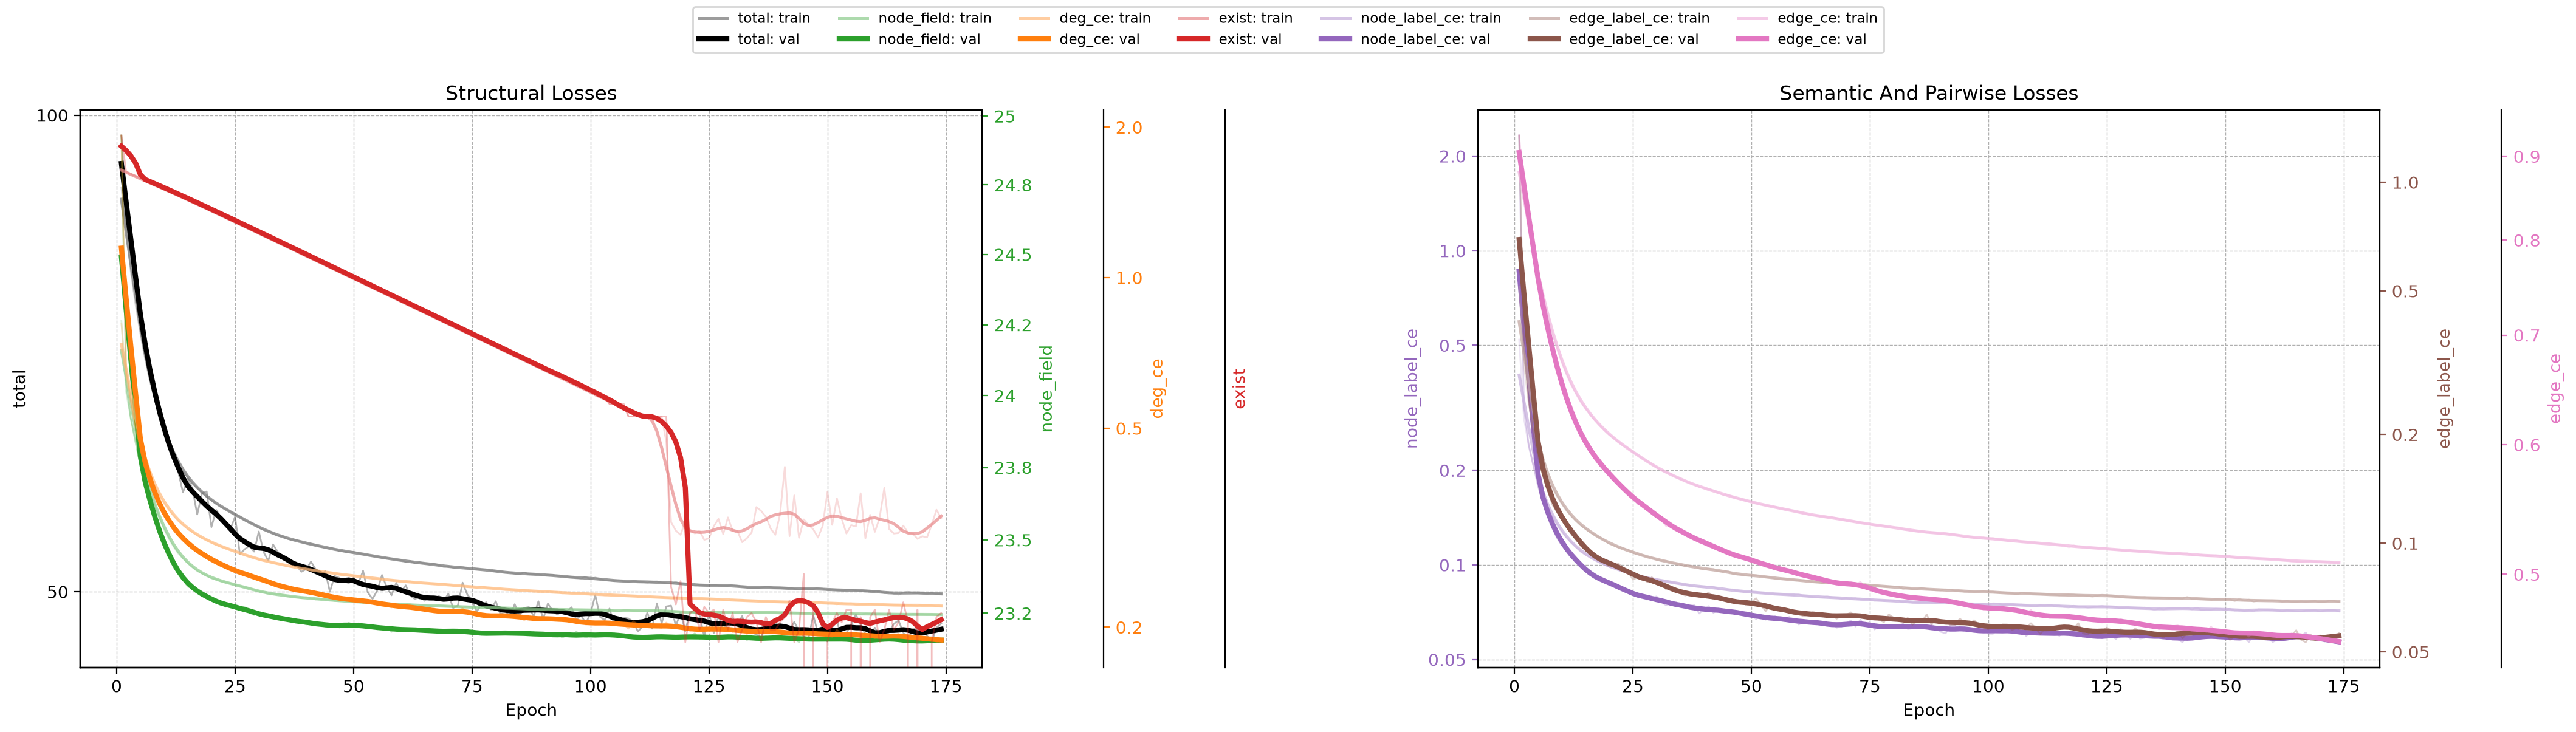

python(93562) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Saved graph generator loss curves as: zinc-d80-n108642-size10-22.loss-curves.pdf
/Users/f.costa/Code/NodeField/.artifacts/saved_generators/zinc-d80-n108642-size10-22.loss-curves.pdf
Saved graph generator as: zinc-d80-n108642-size10-22.pkl
/Users/f.costa/Code/NodeField/.artifacts/saved_generators/zinc-d80-n108642-size10-22.pkl


python(93566) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


CPU times: user 1h 40min 31s, sys: 41min 15s, total: 2h 21min 46s
Wall time: 3h 30min 56s


In [10]:
%%time
# Fit the graph generator on the cached ZINC training molecules.
graph_generator = fit_graph_generator(
    graph_generator,
    train_graphs,
    resume_latest_checkpoint=False,
    checkpoint_root=CHECKPOINT_ROOT,
)


In [11]:
list_saved_graph_generators(SAVED_GENERATOR_ROOT)

,name,modified,size_mb
0,zinc-d80-n108642-size10-22.pkl,2026-07-17 01:13,226.300000
1,artificial-cycle-path-star-n50000-c-3-8-p2-r3x1-d128-b128-e350.pkl,2026-07-17 01:06,61.000000
2,zinc-d80-n10000-size10-18.pkl,2026-07-16 16:23,32.100000
3,zinc-d80-n2250-size10-18.pkl,2026-07-16 15:39,16.900000
4,zinc-d80-n225-size10-18.pkl,2026-07-16 15:20,12.300000
5,artificial-cycle-path-star-n10000-c-3-8-p2-r3x1-d128-b128-e350.pkl,2026-07-16 15:12,21.300000
6,artificial-cycle-path-star-n1000-c-3-8-p2-r3x1-d128-b128-e350.pkl,2026-07-16 14:46,12.400000
7,artificial-cycle-path-star-n100-c-3-8-p2-r3x1-d128-b128-e350.pkl,2026-07-16 13:33,11.000000


['zinc-d80-n108642-size10-22.pkl',
 'artificial-cycle-path-star-n50000-c-3-8-p2-r3x1-d128-b128-e350.pkl',
 'zinc-d80-n10000-size10-18.pkl',
 'zinc-d80-n2250-size10-18.pkl',
 'zinc-d80-n225-size10-18.pkl',
 'artificial-cycle-path-star-n10000-c-3-8-p2-r3x1-d128-b128-e350.pkl',
 'artificial-cycle-path-star-n1000-c-3-8-p2-r3x1-d128-b128-e350.pkl',
 'artificial-cycle-path-star-n100-c-3-8-p2-r3x1-d128-b128-e350.pkl']

In [12]:
# Resume later with a copied filename from the save cell. 
if False:
    MODEL_FILENAME = 'zinc-d64-n10000-size10-18.pkl'  # Replace with your chosen filename from the list above.
    graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)

## Inspect Masking And Bond Labels

Before decoding, inspect the latent predictions directly on a small batch of cached ZINC molecules.

python(93745) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93770) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93774) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93790) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93794) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93807) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93811) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93829) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93831) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93851) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(93856) Malloc

,conditioning_nodes,raw_predicted_nodes,decoded_support_nodes,conditioning_edges,raw_expected_edges,decoded_edges
0,20,22,20,20,47.905038,20
1,22,22,22,23,61.030128,23
2,15,22,15,16,40.175866,16
3,22,22,22,24,93.501636,24
4,19,22,19,20,66.702456,20
5,20,22,20,21,68.921904,21
6,18,22,18,19,49.363854,19


,graph_idx,double,single,aromatic,triple
0,0,60,424,0.0,0.0
1,1,38,233,213.0,0.0
2,2,1,402,81.0,0.0
3,3,16,218,250.0,0.0
4,4,104,145,235.0,0.0
5,5,68,415,1.0,0.0
6,6,11,261,177.0,35.0


Decoded molecules from the inspected latent batch


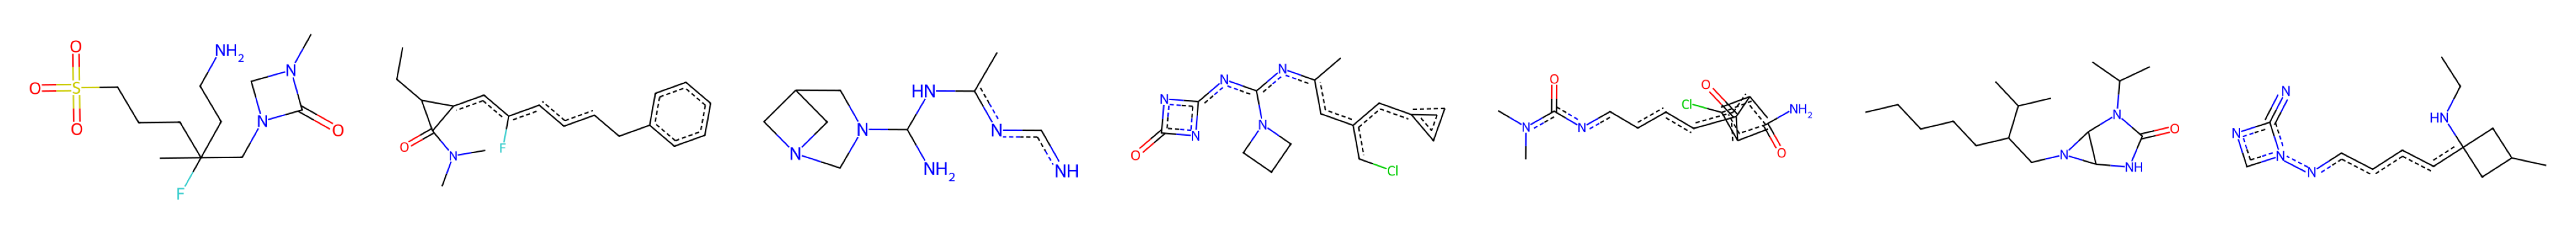

CPU times: user 1.74 s, sys: 834 ms, total: 2.58 s
Wall time: 3.43 s


In [13]:
%%time
# Inspect predicted node masks and bond-label logits before full decoding.
inspected_nodes, inspected_graphs = inspect_predicted_masks_and_edge_labels(
    graph_generator,
    train_graphs[:7],
    n_graphs=7,
)

## Conditional Molecule Sampling

The sampling examples below condition on held-out ZINC molecules and draw the generated molecules with the chemistry-specific routines.

python(94359) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94386) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94420) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94421) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94426) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94427) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94430) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94431) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94433) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94434) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94443) Malloc

Feasibility attempt  1/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=   53.4s | eta=8m 54.0s


python(95132) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(95165) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(95680) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(95681) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(95703) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(95704) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(95714) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(95715) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(95753) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(95754) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(95763) Malloc

Feasibility attempt  2/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 13.2s | eta=9m 29.7s


python(96964) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96965) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96966) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96967) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96968) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96969) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96970) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96971) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96972) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96973) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(96974) Malloc

...

Feasibility attempt 10/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=    3.6s | eta=   15.8s


python(97288) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97297) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97298) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97299) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97300) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97301) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97302) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97304) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97305) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97306) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97307) Malloc

Feasibility attempt 11/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=    3.6s | eta=    0.0s
Feasibility filtering summary: generated=33, feasible_candidates=0, feasible_rate=0.0%, fulfilled_slots=0/1.


python(97344) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97345) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97346) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97347) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97348) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97349) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97350) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97351) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97354) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97355) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(97358) Malloc

Feasibility attempt  1/11 | generated=   3 | feasible_candidates= 2 | feasible_rate= 66.7% | attempt_time=   32.4s | eta=    0.0s
Feasibility filtering summary: generated=3, feasible_candidates=2, feasible_rate=66.7%, fulfilled_slots=1/1.
Generation summary: requested=2, returned=2, generated=36, candidate_feasible=2 (5.6%), feasible=1 (50.0%), unfiltered=1 (50.0%), rejected=0 (0.0%).
Raw decoded ZINC molecules


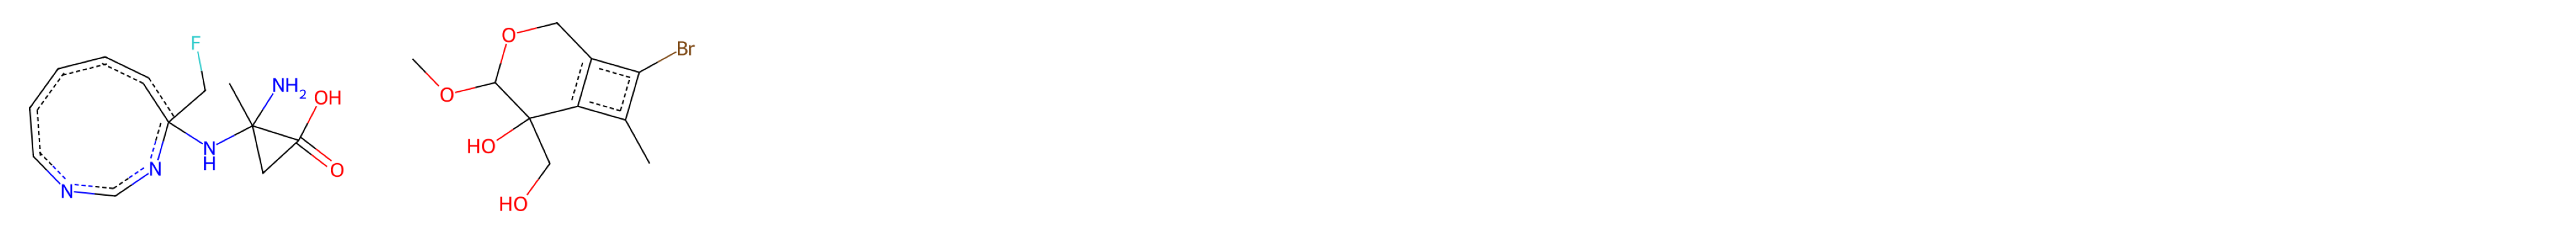

CPU times: user 2min 36s, sys: 16.6 s, total: 2min 53s
Wall time: 3min 15s


In [14]:
%%time
graph_generator.feasibility_candidates_per_attempt=3
# Generate raw conditional samples from held-out ZINC molecules.
raw_samples = graph_generator.sample_conditioned_on_random(
    test_graphs,
    n_samples=2,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)
show_molecules(raw_samples, n=len(raw_samples), title='Raw decoded ZINC molecules')

### Seed vs Sample Comparison

Show each seed molecule next to generated variants so feasibility filtering is easy to inspect.

apply_feasibility_filtering=True, feasibility_oracle_candidates_per_attempt=0
Held-out ZINC conditioning set: conditioning molecules


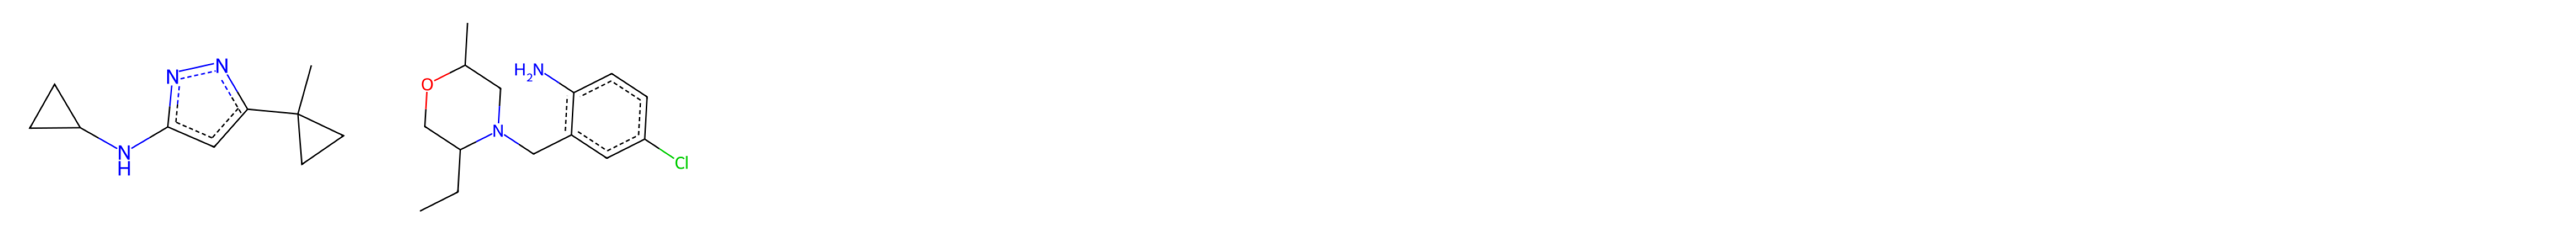

python(98642) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98643) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98644) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98645) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98646) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98647) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Held-out ZINC conditioning set: generated molecules without feasibility


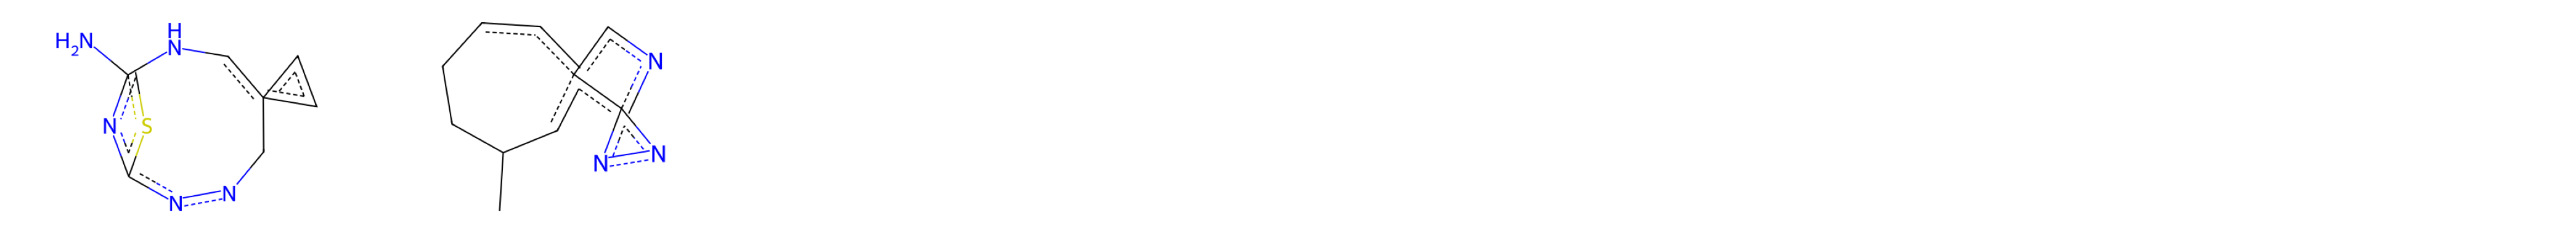

python(98648) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98649) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98650) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98651) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98652) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98653) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98654) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98655) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98656) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98657) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98658) Malloc

Feasibility attempt  1/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=    3.5s | eta=   35.2s


python(98682) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98683) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98684) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98685) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98686) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98687) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98688) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98689) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98690) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98691) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98692) Malloc

Feasibility attempt  2/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=    3.5s | eta=   31.6s


python(98714) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98715) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98716) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98717) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98718) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98719) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98720) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98721) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98722) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98723) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98724) Malloc

...

Feasibility attempt  5/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=    3.7s | eta=   22.6s


python(510) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(511) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(512) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(513) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(514) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(515) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(518) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(530) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(532) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(534) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(546) MallocStackLogging: can't tu

Feasibility attempt  6/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=    3.8s | eta=   18.8s


python(596) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(597) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(598) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(604) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(605) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(606) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(607) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(608) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(609) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(610) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(611) MallocStackLogging: can't tu

Feasibility attempt  7/11 | generated=   3 | feasible_candidates= 1 | feasible_rate= 33.3% | attempt_time=   13.1s | eta=    0.0s
Feasibility filtering summary: generated=21, feasible_candidates=1, feasible_rate=4.8%, fulfilled_slots=1/1.
Generation summary: requested=2, returned=2, generated=54, candidate_feasible=1 (1.9%), feasible=1 (50.0%), unfiltered=1 (50.0%), rejected=0 (0.0%).
Held-out ZINC conditioning set: generated molecules with feasibility


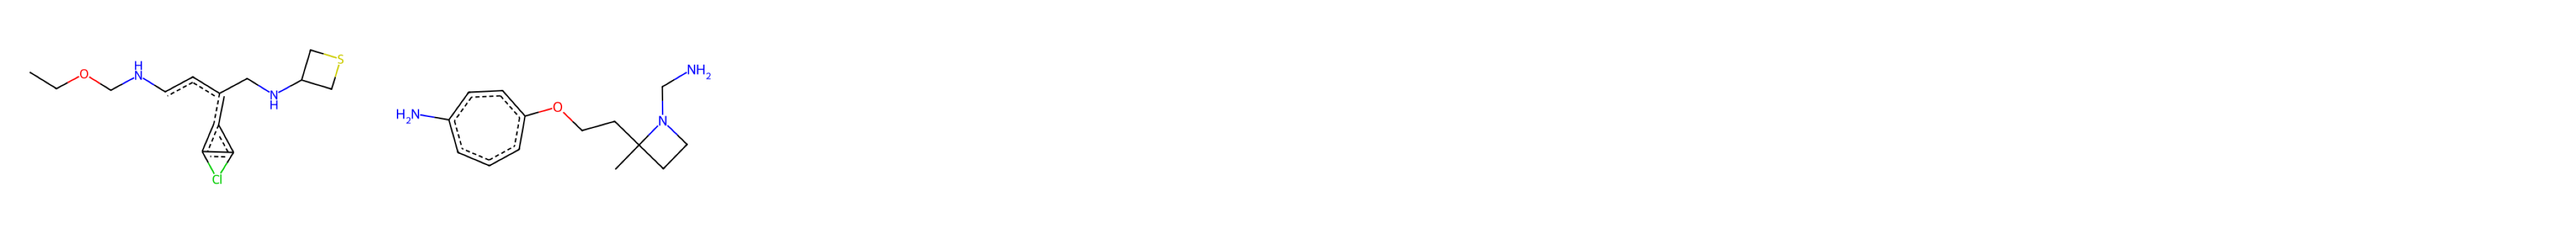

--------------------------------------------------------------------------------
apply_feasibility_filtering=False, feasibility_oracle_candidates_per_attempt=2
Held-out ZINC conditioning set: conditioning molecules


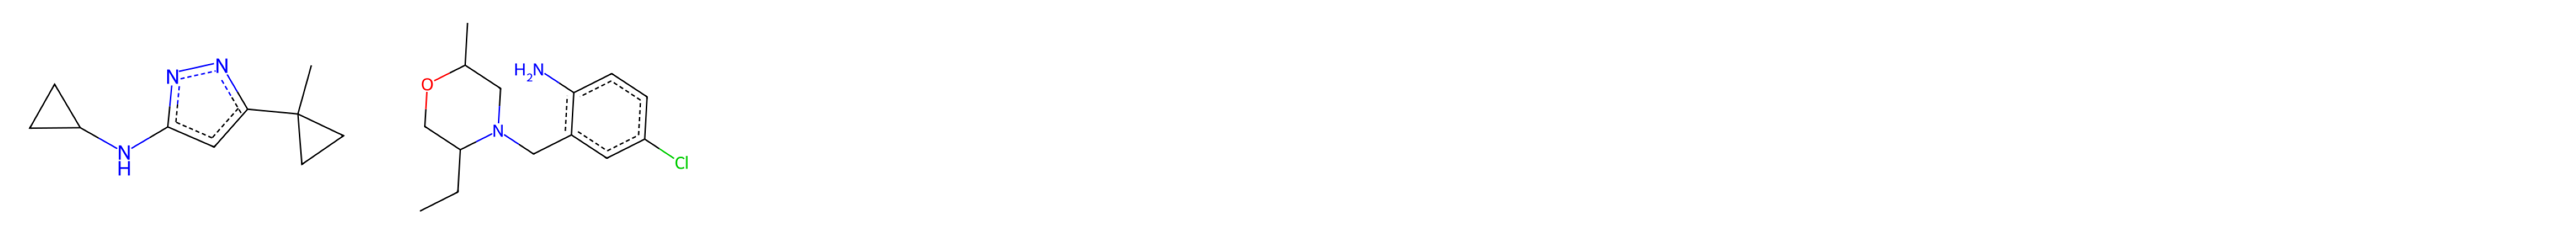

python(768) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(769) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(811) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(812) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(813) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(814) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(815) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(816) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(968) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(969) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(1576) MallocStackLogging: can't t

Held-out ZINC conditioning set: generated molecules without feasibility


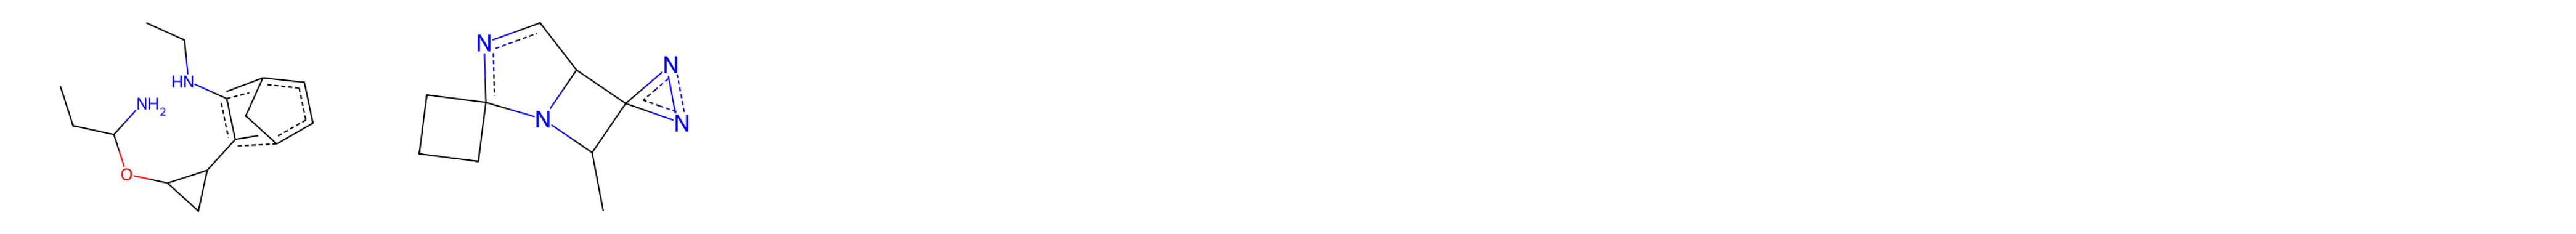

--------------------------------------------------------------------------------
apply_feasibility_filtering=True, feasibility_oracle_candidates_per_attempt=2
Held-out ZINC conditioning set: conditioning molecules


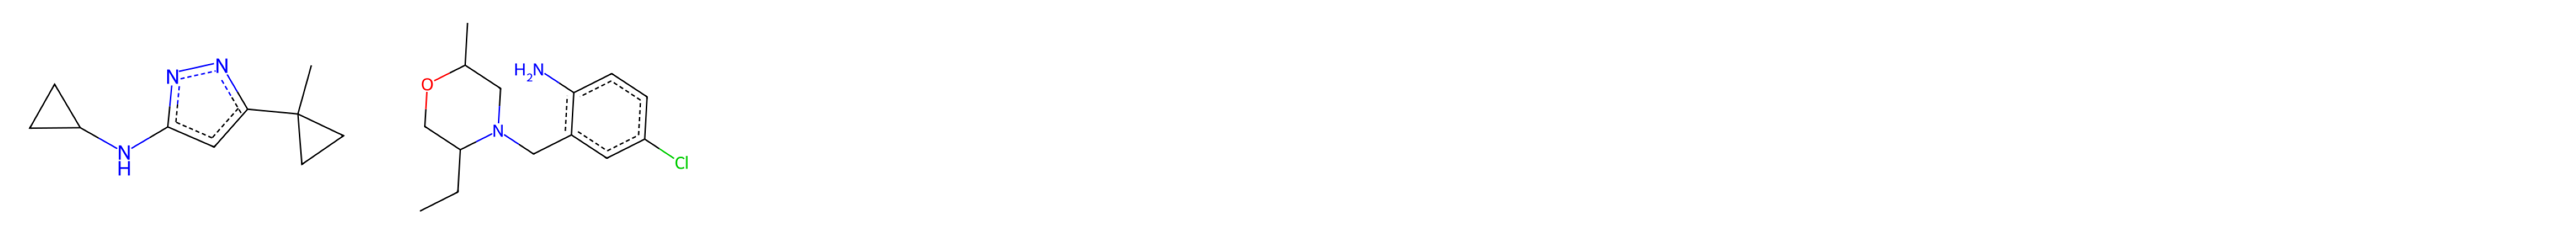

python(2022) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2024) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2039) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2042) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2043) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2044) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2045) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2046) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2063) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2064) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2067) MallocStackLoggin

Held-out ZINC conditioning set: generated molecules without feasibility


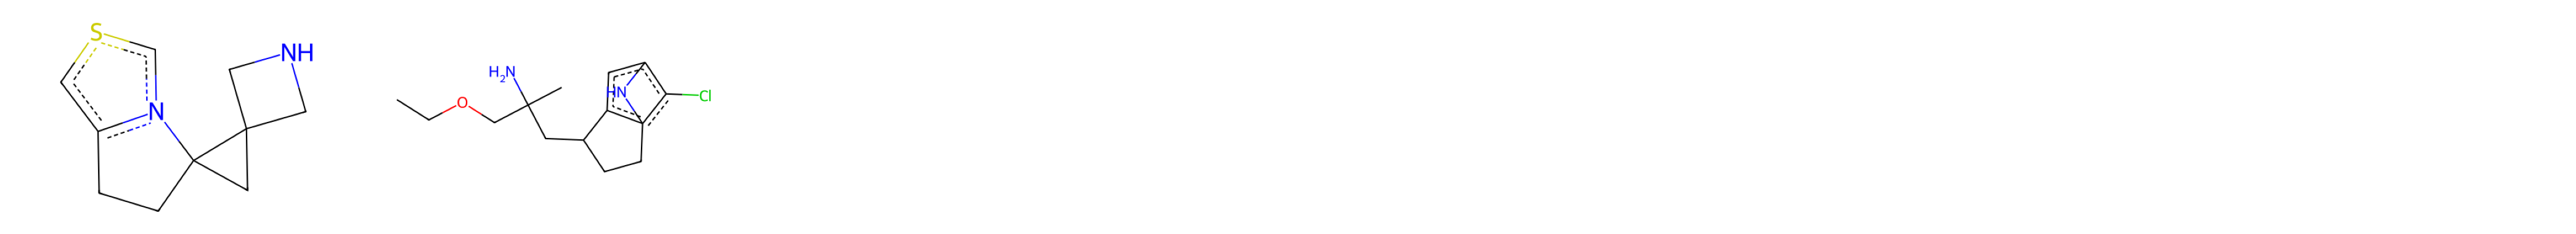

python(2078) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2080) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2082) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2083) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2085) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2086) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2089) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2090) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2281) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2282) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2477) MallocStackLoggin

Feasibility attempt  1/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 01.8s | eta=10m 18.1s


python(3587) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3591) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3607) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3608) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3611) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3612) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3617) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3618) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3629) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3630) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3700) MallocStackLoggin

Feasibility attempt  2/11 | generated=   3 | feasible_candidates= 1 | feasible_rate= 33.3% | attempt_time=   49.1s | eta=    0.0s
Feasibility filtering summary: generated=6, feasible_candidates=1, feasible_rate=16.7%, fulfilled_slots=1/1.


python(5048) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5049) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5050) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5051) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5061) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5065) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5073) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5074) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5077) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5078) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(5082) MallocStackLoggin

...

Feasibility attempt 10/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=    3.8s | eta=   14.1s


python(7821) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7822) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7823) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7824) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7825) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7826) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7827) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7828) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7829) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7830) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7831) MallocStackLoggin

Feasibility attempt 11/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=    3.8s | eta=    0.0s
Feasibility filtering summary: generated=33, feasible_candidates=0, feasible_rate=0.0%, fulfilled_slots=0/1.
Generation summary: requested=2, returned=2, generated=39, candidate_feasible=1 (2.6%), feasible=1 (50.0%), unfiltered=1 (50.0%), rejected=0 (0.0%).


python(7848) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7849) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Held-out ZINC conditioning set: generated molecules with feasibility


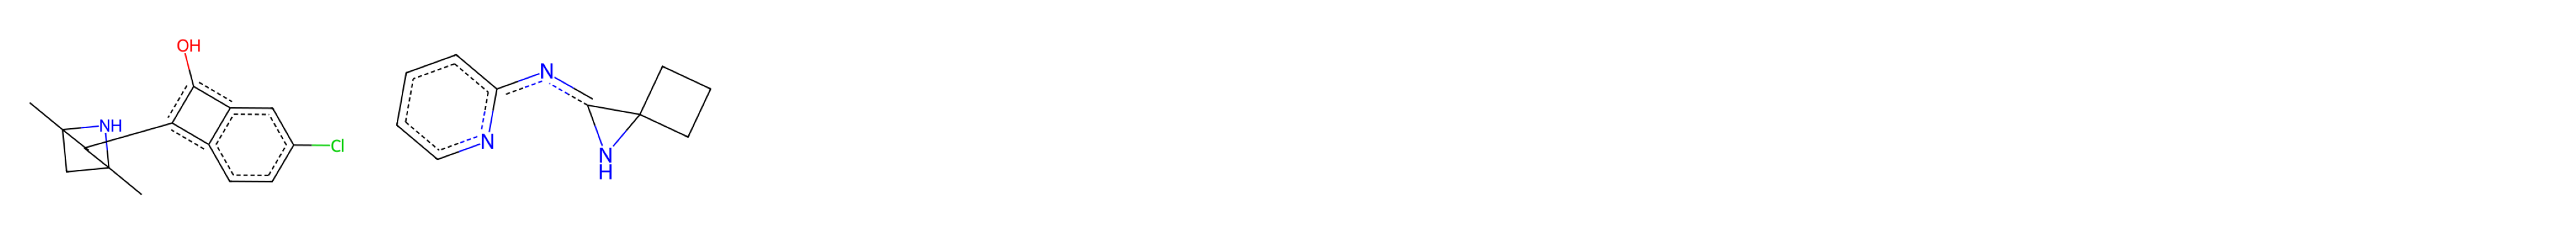

In [15]:
# Show the seed molecules next to unfiltered and feasibility-filtered samples.
N_SEEDS = 2

print('apply_feasibility_filtering=True, feasibility_oracle_candidates_per_attempt=0')
show_seed_and_samples(
    graph_generator,
    test_graphs,
    n_seeds=N_SEEDS,
    title='Held-out ZINC conditioning set',
    apply_feasibility_filtering=True,
    feasibility_oracle_candidates_per_attempt=0,
)

print('-'*80)
print(f'apply_feasibility_filtering=False, feasibility_oracle_candidates_per_attempt={FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT}')
show_seed_and_samples(
    graph_generator,
    test_graphs,
    n_seeds=N_SEEDS,
    title='Held-out ZINC conditioning set',
    apply_feasibility_filtering=False,
    feasibility_oracle_candidates_per_attempt=FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT,
)

print('-'*80)
print(f'apply_feasibility_filtering=True, feasibility_oracle_candidates_per_attempt={FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT}')
show_seed_and_samples(
    graph_generator,
    test_graphs,
    n_seeds=N_SEEDS,
    title='Held-out ZINC conditioning set',
    apply_feasibility_filtering=True,
    feasibility_oracle_candidates_per_attempt=FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT,
)


## Random Endpoint Interpolation

Select two training molecules at random, interpolate between them, and display the endpoints plus generated intermediate molecules.

Endpoint indices: [47568, 93149]
Endpoint A SMILES: O=C(NCc1cc(Br)ccc1F)N1CCOC[C@@H]1C1CC1

Endpoint B SMILES: CCSCCC(=O)N1CCN(Cc2ccc(Cl)cc2)CC1

Selected endpoint molecules


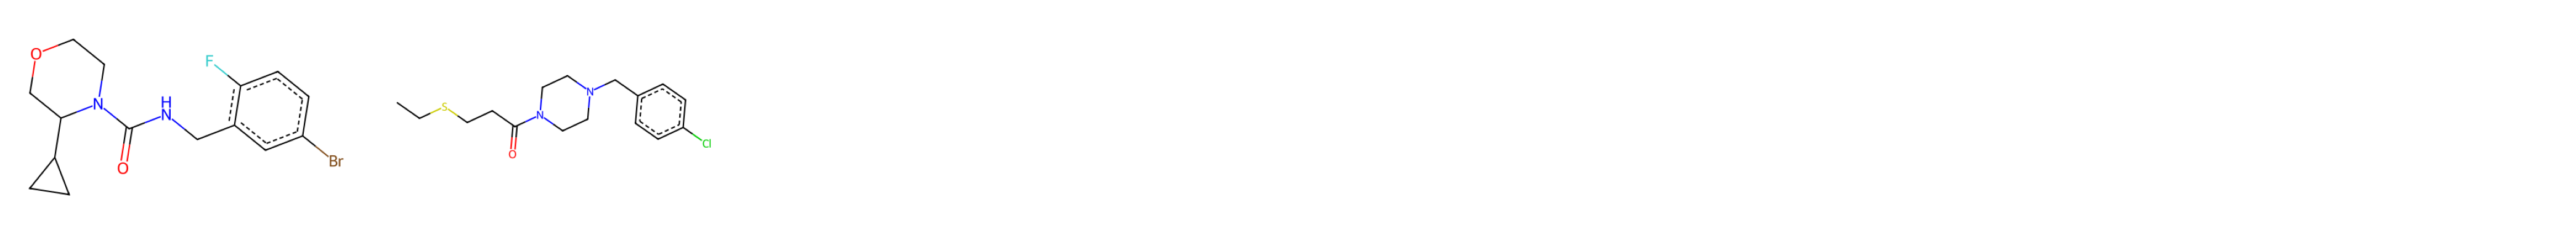

python(7850) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(7851) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8538) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8615) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8977) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8978) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8989) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8990) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(9003) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(9004) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(9005) MallocStackLoggin

Feasibility attempt  1/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 14.2s | eta=12m 22.0s


python(10181) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10182) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10184) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10185) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10187) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10188) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10189) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10190) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10193) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10194) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10197) Malloc

Feasibility attempt  2/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 08.3s | eta=10m 41.3s


python(11361) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11362) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11363) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11364) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11365) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11366) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11367) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11368) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11369) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11370) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11371) Malloc

...

Feasibility attempt 11/11 | generated=   3 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=    3.8s | eta=    0.0s
Feasibility filtering summary: generated=33, feasible_candidates=0, feasible_rate=0.0%, fulfilled_slots=0/1.


python(17883) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17884) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Generation summary: requested=3, returned=3, generated=72, candidate_feasible=2 (2.8%), feasible=1 (33.3%), unfiltered=2 (66.7%), rejected=0 (0.0%).


,step,t,target_nodes,target_edges,decoded,mode
0,1,0.25,21,23,True,slerp
1,2,0.50,21,22,True,slerp
2,3,0.75,21,22,True,slerp


Endpoints and generated interpolation molecules


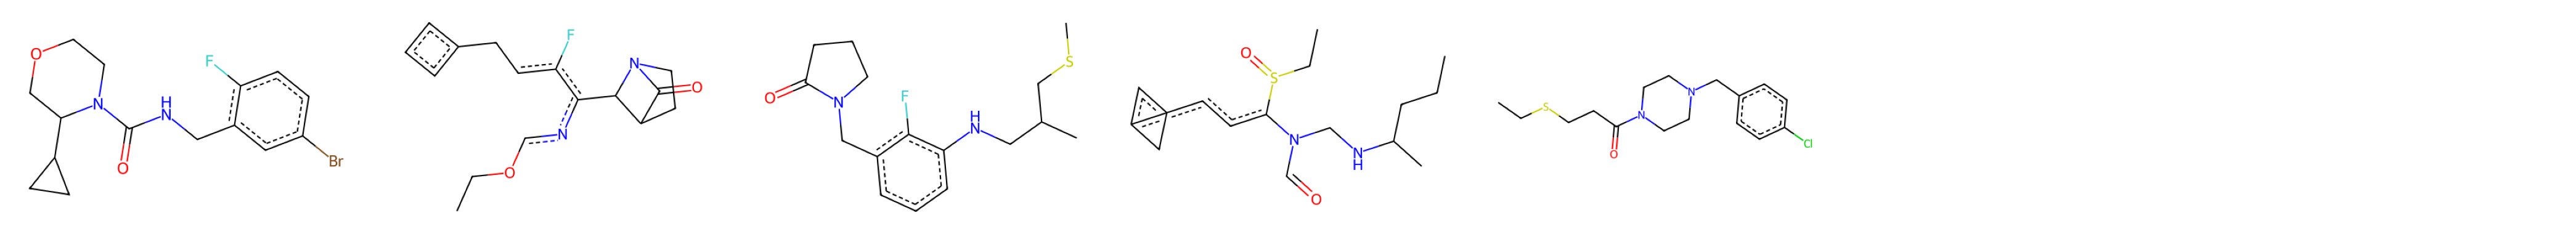

CPU times: user 5min 59s, sys: 35.7 s, total: 6min 35s
Wall time: 7min 20s


In [16]:
%%time
# Interpolate between two random training molecules and decode the intermediate trajectory.
selected_indices, endpoint_graph_a, endpoint_graph_b = sample_random_endpoint_pair(train_graphs)
print('Endpoint indices:', selected_indices)
print('Endpoint A SMILES:', endpoint_graph_a.graph.get('smiles'))
print('Endpoint B SMILES:', endpoint_graph_b.graph.get('smiles'))

show_molecules([endpoint_graph_a, endpoint_graph_b], n=2, title='Selected endpoint molecules')

interpolation_result = graph_generator.interpolate(
    endpoint_graph_a,
    endpoint_graph_b,
    k=3,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)
display(interpolation_result['summary'])

missing_steps = interpolation_result['summary'].loc[
    ~interpolation_result['summary']['decoded'],
    'step',
].tolist()
if missing_steps:
    print('Interpolation steps rejected by feasibility filtering:', missing_steps)

show_molecules(
    [endpoint_graph_a, *interpolation_result['generated_graphs'], endpoint_graph_b],
    n=len(interpolation_result['generated_graphs']) + 2,
    title='Endpoints and generated interpolation molecules',
)

## Stochastic Training-Embedding Sampling

Sample new graph-level conditioning vectors by interpolating between pairs of cached training embeddings, then decode and display the resulting molecules.

python(17885) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17886) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17887) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17888) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17889) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17890) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17891) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17892) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17893) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17894) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17895) Malloc

Decoded stochastic interpolation samples: 35
Samples from stochastic training-embedding interpolation


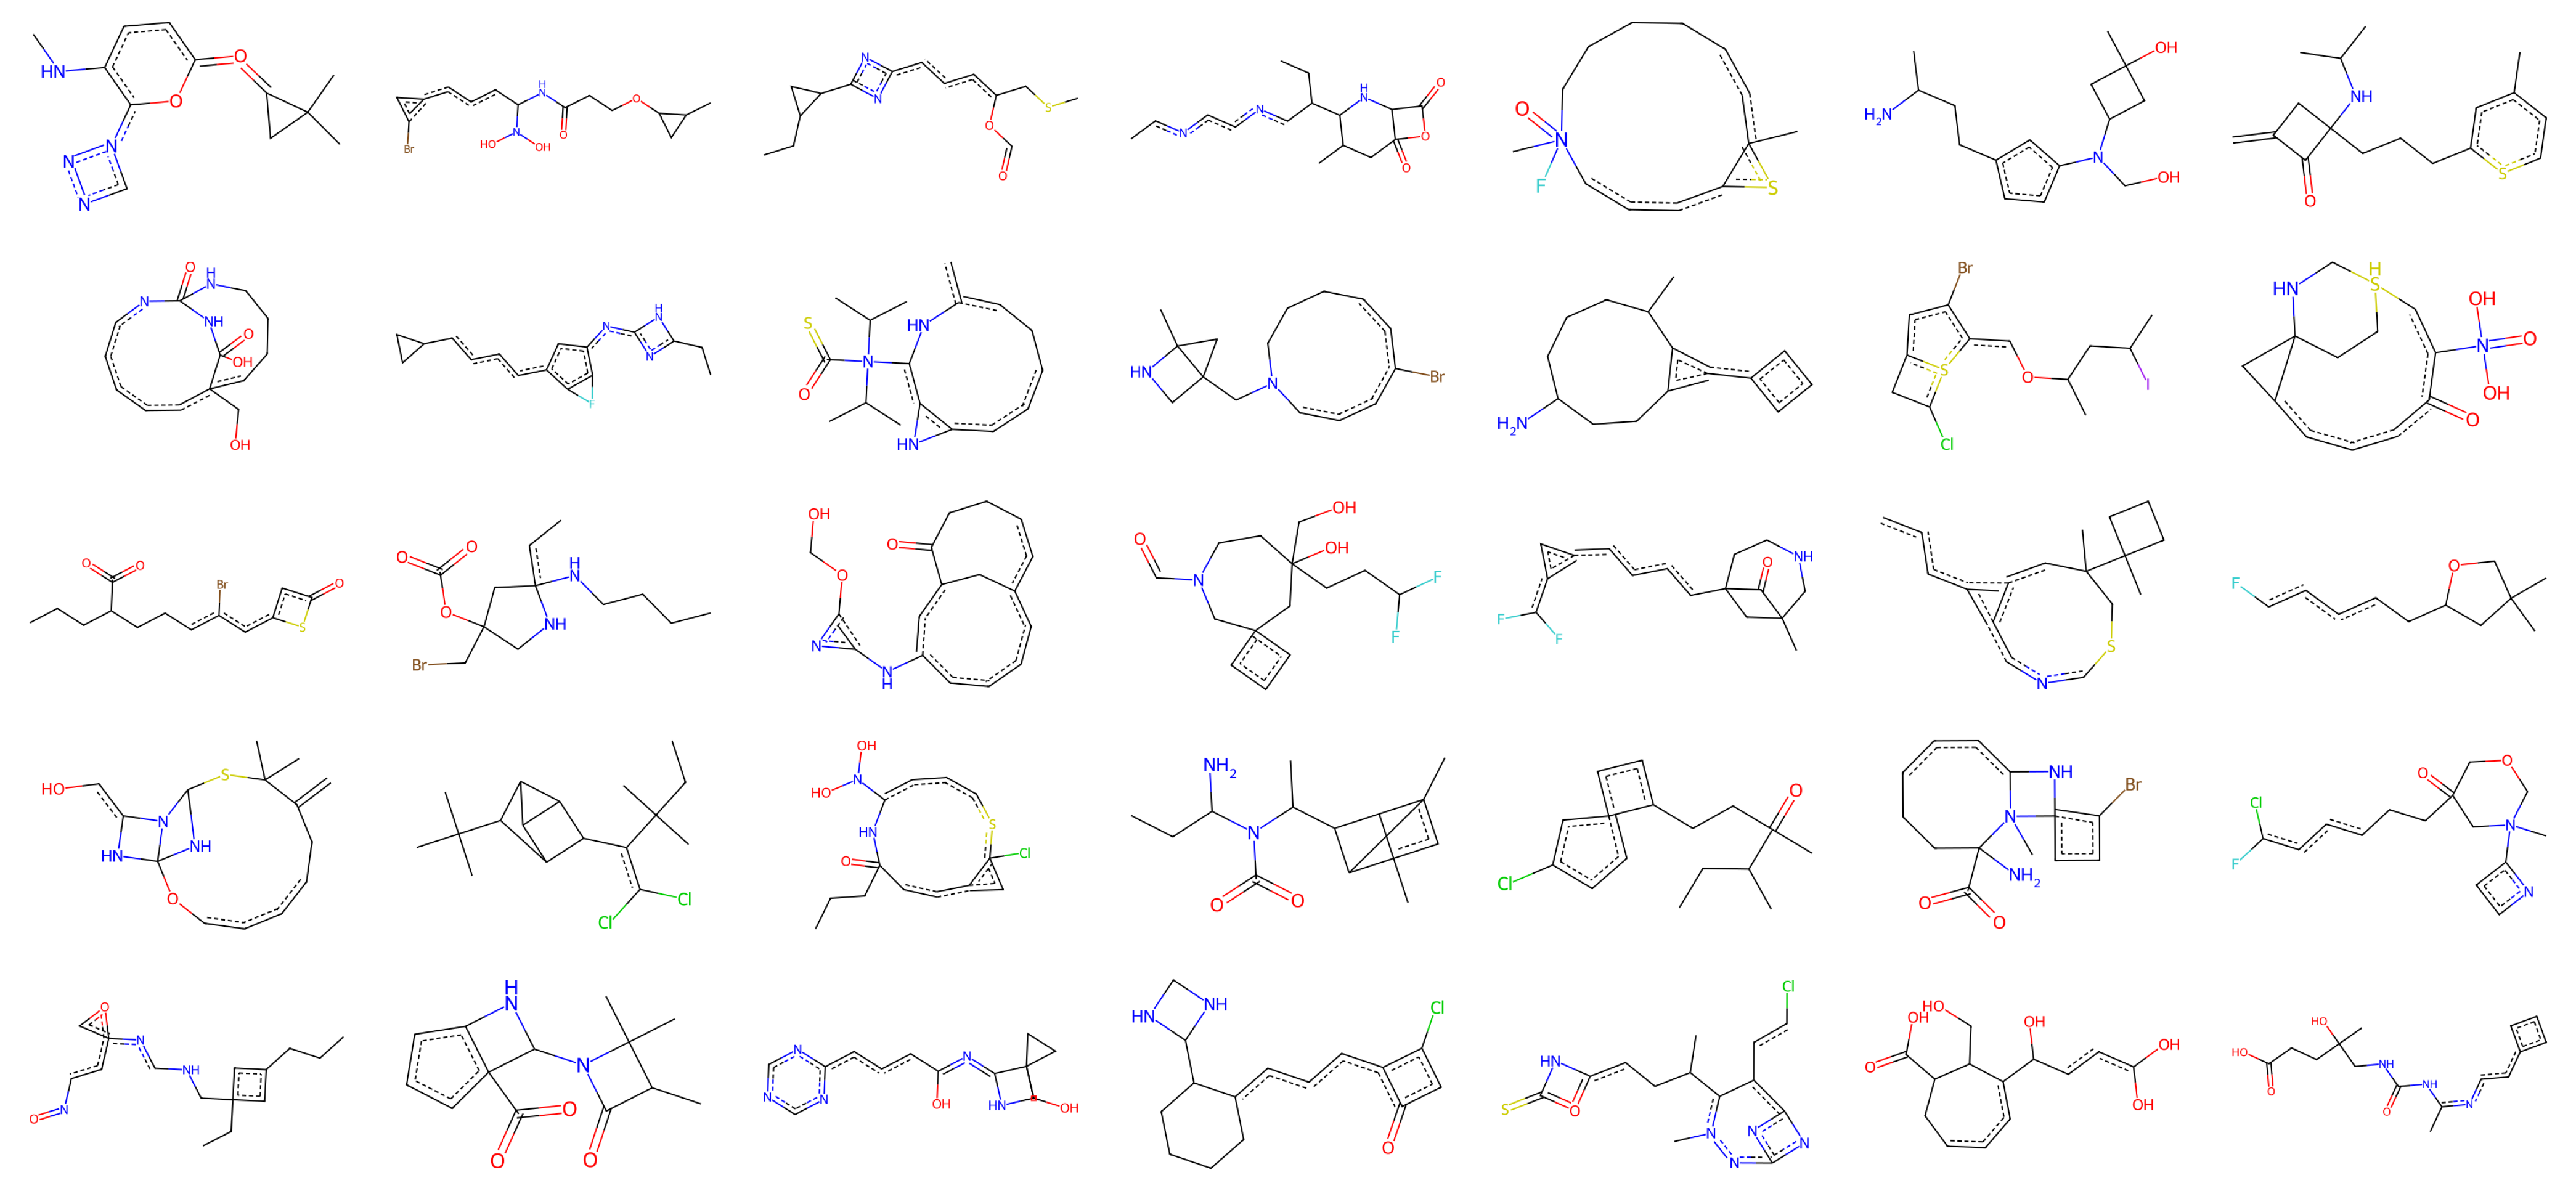

CPU times: user 7.48 s, sys: 2.69 s, total: 10.2 s
Wall time: 11.6 s


In [17]:
%%time
# Sample fresh graph-level conditions from cached training embeddings and decode them.
n_samples = 7 * 5
interpolated_samples = graph_generator.sample(
    n_samples=n_samples,
    interpolate_between_n_samples=10,
    apply_feasibility_filtering=False,
)

print('Decoded stochastic interpolation samples:', len(interpolated_samples))
show_molecules(
    interpolated_samples,
    title='Samples from stochastic training-embedding interpolation',
    n=n_samples
)

Samples from stochastic training-embedding interpolation


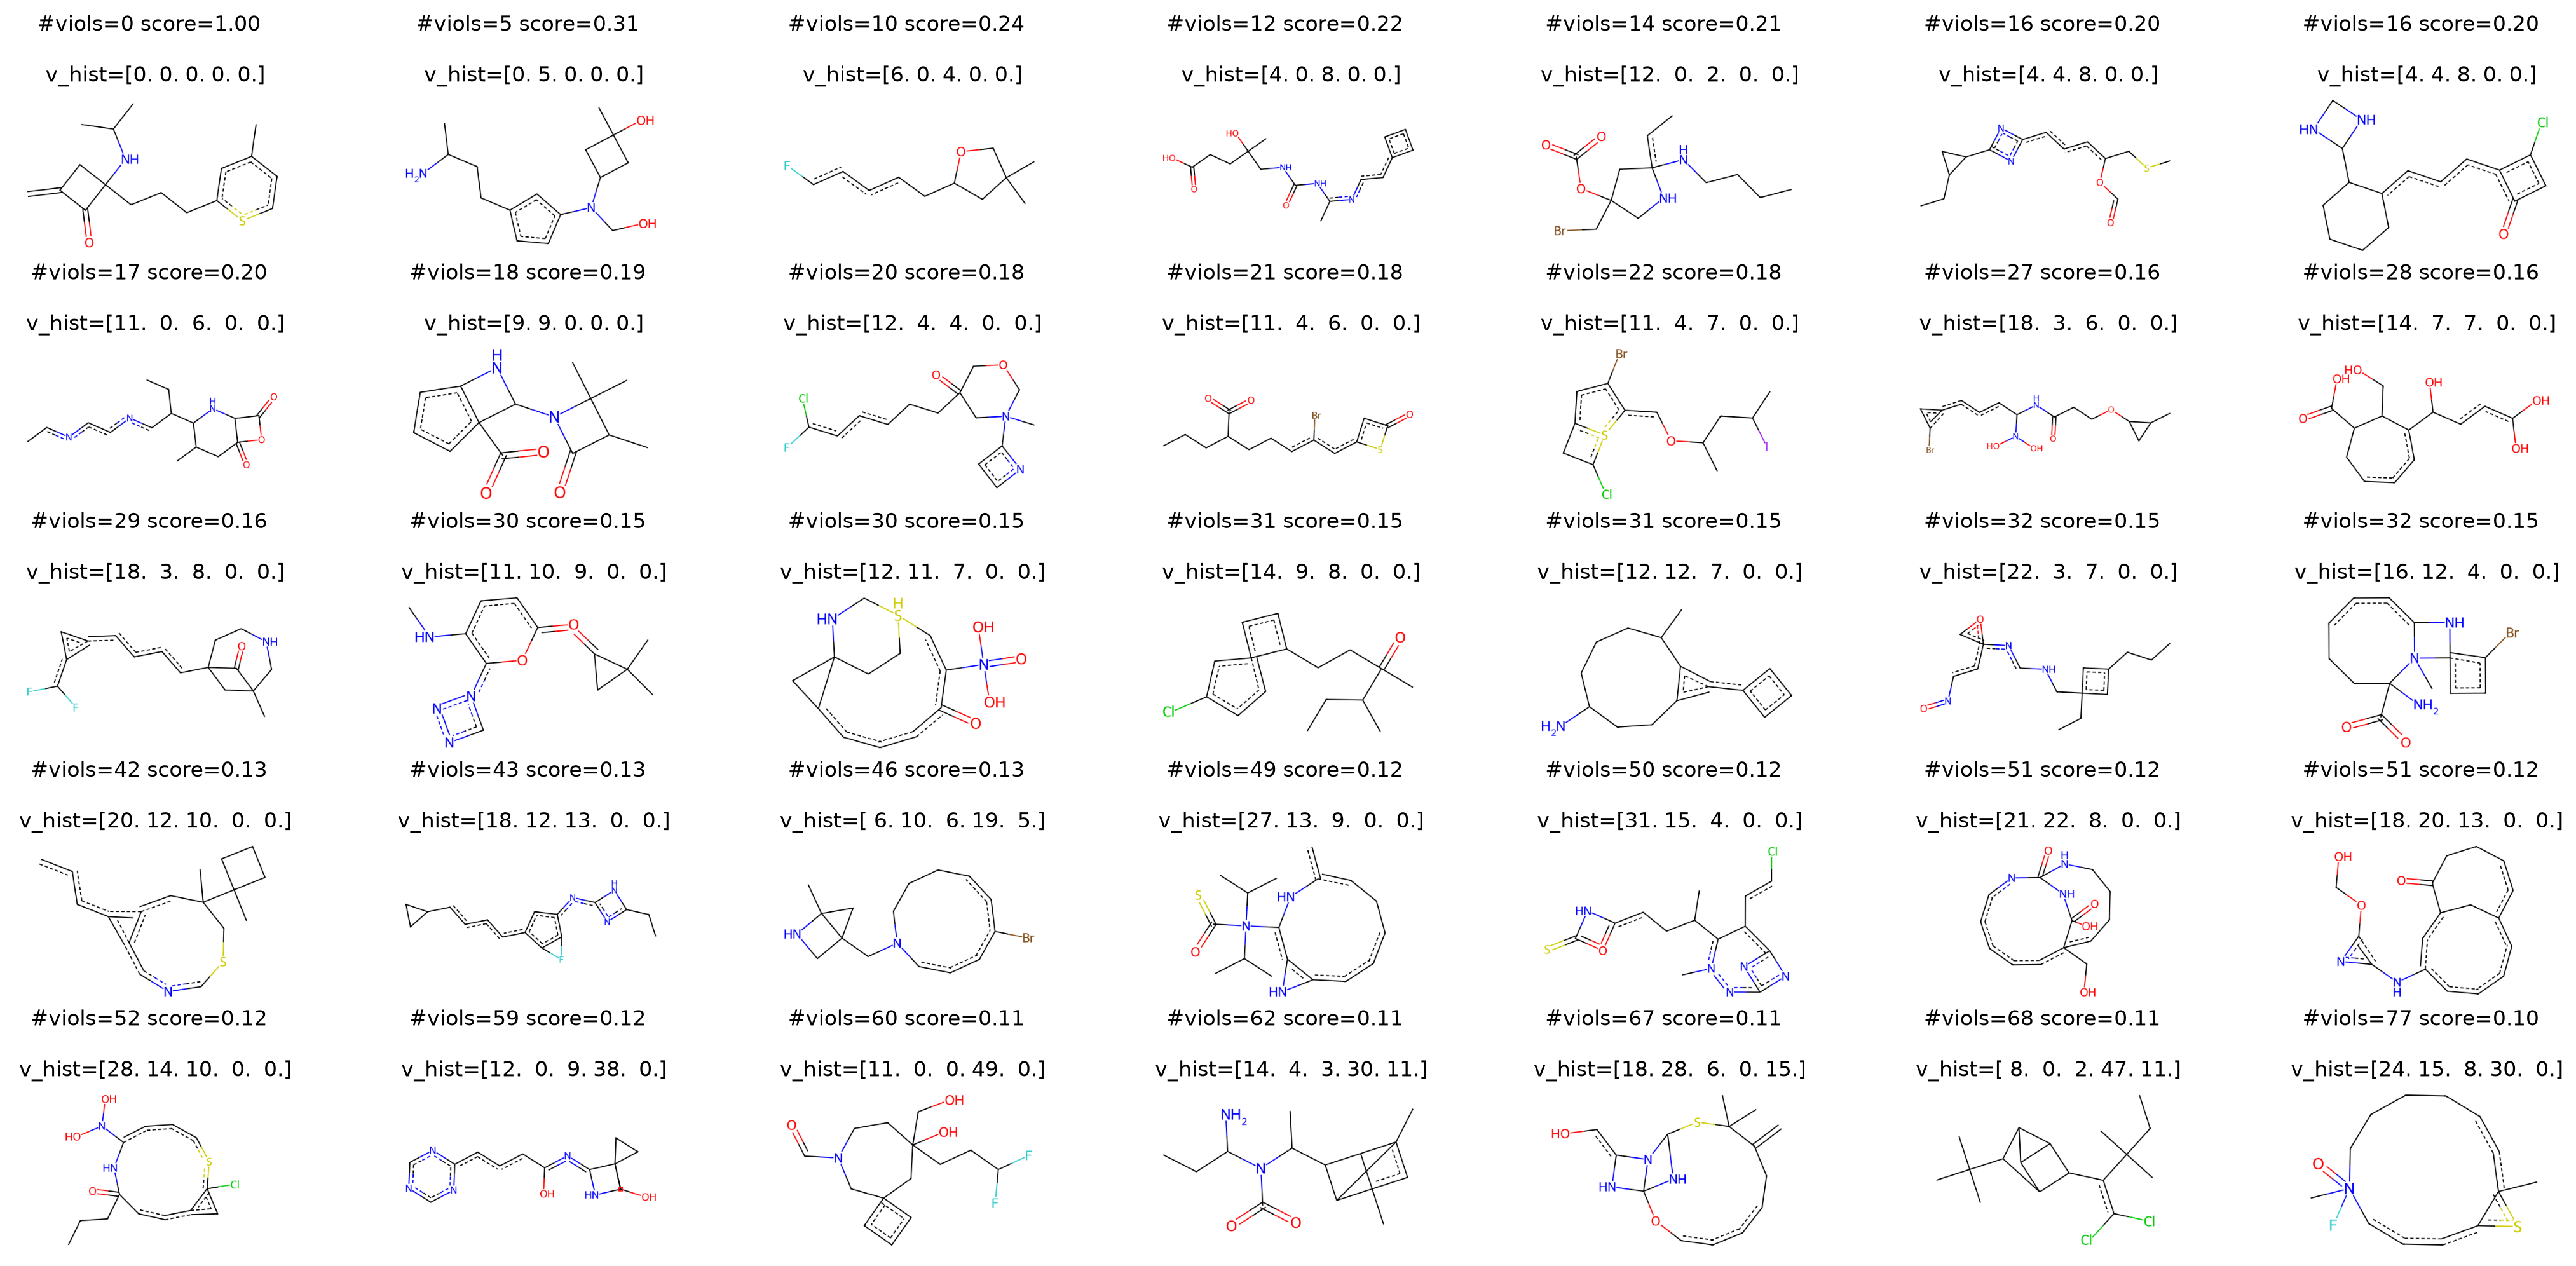

CPU times: user 2.9 s, sys: 42.6 ms, total: 2.94 s
Wall time: 2.94 s


In [18]:
%%time
#number_of_violations
from math import log1p, sqrt
interpolated_samples_number_of_violations = graph_generator.feasibility_estimator.number_of_violations(interpolated_samples)
interpolated_samples_violations = graph_generator.feasibility_estimator.violations(interpolated_samples)
def  score(number_of_violations): return 1 / (1 + sqrt(number_of_violations))

idxs = np.argsort(interpolated_samples_number_of_violations)
sorted_interpolated_samples = [interpolated_samples[int(i)] for i in idxs]
sorted_interpolated_samples_number_of_violations = [interpolated_samples_number_of_violations[int(i)] for i in idxs]
sorted_interpolated_samples_violations = [interpolated_samples_violations[int(i)] for i in idxs]
show_molecules(
    sorted_interpolated_samples,
    title='Samples from stochastic training-embedding interpolation',
    n=len(interpolated_samples),
    legends=[f"#viols={int(v):d} score={score(v):.2f} \n \n v_hist={vs}" for v,vs in zip(sorted_interpolated_samples_number_of_violations, sorted_interpolated_samples_violations)],
)